**MADOUNGOU Colombe Alice**

**TA Khanh Vy**

**Problématique**: Comment analyser les données de ventes e-commerce afin d’identifier les facteurs influençant le chiffre d’affaires et optimiser la performance commerciale ?

Dataset: https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data



In [9]:
#import des packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# **Étude de dataset**

In [10]:
#chargement du df
df_amazon= pd.read_csv('/content/Amazon Sale Report.csv', delimiter=',')
df_amazon.head(5)

/tmp/ipykernel_1251/759720894.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_amazon= pd.read_csv('/content/Amazon Sale Report.csv', delimiter=',')


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [11]:
#infos sur les dataframe
print("--- df_amazon Info ---")
df_amazon.info()
print("\n--- df_amazon Shape ---")
print(df_amazon.shape)

--- df_amazon Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount     

# **Nettoyage des données**


In [12]:
 #  Vérification des doublons
nb_doublons = df_amazon.duplicated().sum()
print(f"Nombre de lignes en double : {nb_doublons}")

 # afficher les valeurs manquantes
df_amazon.isnull().sum()


Nombre de lignes en double : 0


,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [13]:
#nettoyage des colonnes
# supprimer les espaces vides (invisibles) au début et à la fin des noms de colonnes.
df_amazon.columns = df_amazon.columns.str.strip()

deleted_columns_list = ['index', 'Unnamed: 22','ASIN', 'ship-postal-code', 'ship-country','currency', 'Sales Channel','fulfilled-by', 'ship-service-level','Courier Status']

# Identifier lesquelles des colonnes de la liste sont réellement présentes dans le df
columns_to_drop_now = [col for col in deleted_columns_list if col in df_amazon.columns]

if columns_to_drop_now:
    df_amazon = df_amazon.drop(columns=columns_to_drop_now, axis=1)
    print(f"Colonnes supprimées avec succès: {columns_to_drop_now}")
else:
    print("Aucune des colonnes spécifiées n'a été trouvée (elles sont déjà supprimées).")

print(df_amazon.columns.tolist())

df_amazon.head(10)

Colonnes supprimées avec succès: ['index', 'Unnamed: 22', 'ASIN', 'ship-postal-code', 'ship-country', 'currency', 'Sales Channel', 'fulfilled-by', 'ship-service-level', 'Courier Status']
['Order ID', 'Date', 'Status', 'Fulfilment', 'Style', 'SKU', 'Category', 'Size', 'Qty', 'Amount', 'ship-city', 'ship-state', 'promotion-ids', 'B2B']


,Order ID,Date,Status,Fulfilment,Style,SKU,Category,Size,Qty,Amount,ship-city,ship-state,promotion-ids,B2B
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,SET389,SET389-KR-NP-S,Set,S,0,647.62,MUMBAI,MAHARASHTRA,NaN,False
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,JNE3781,JNE3781-KR-XXXL,kurta,3XL,1,406.00,BENGALURU,KARNATAKA,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,04-30-22,Shipped,Amazon,JNE3371,JNE3371-KR-XL,kurta,XL,1,329.00,NAVI MUMBAI,MAHARASHTRA,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,J0341,J0341-DR-L,Western Dress,L,0,753.33,PUDUCHERRY,PUDUCHERRY,NaN,False
4,407-1069790-7240320,04-30-22,Shipped,Amazon,JNE3671,JNE3671-TU-XXXL,Top,3XL,1,574.00,CHENNAI,TAMIL NADU,NaN,False
5,404-1490984-4578765,04-30-22,Shipped,Amazon,SET264,SET264-KR-NP-XL,Set,XL,1,824.00,GHAZIABAD,UTTAR PRADESH,IN Core Free Shipping 2015/04/08 23-48-5-108,False
6,408-5748499-6859555,04-30-22,Shipped,Amazon,J0095,J0095-SET-L,Set,L,1,653.00,CHANDIGARH,CHANDIGARH,IN Core Free Shipping 2015/04/08 23-48-5-108,False
7,406-7807733-3785945,04-30-22,Shipped - Delivered to Buyer,Merchant,JNE3405,JNE3405-KR-S,kurta,S,1,399.00,HYDERABAD,TELANGANA,Amazon PLCC Free-Financing Universal Merchant ...,False
8,407-5443024-5233168,04-30-22,Cancelled,Amazon,SET200,SET200-KR-NP-A-XXXL,Set,3XL,0,NaN,HYDERABAD,TELANGANA,IN Core Free Shipping 2015/04/08 23-48-5-108,False
9,402-4393761-0311520,04-30-22,Shipped,Amazon,JNE3461,JNE3461-KR-XXL,kurta,XXL,1,363.00,Chennai,TAMIL NADU,NaN,False


In [14]:
 # afficher les valeurs manquantes après suppression
df_amazon.isnull().sum()


,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Style,0
SKU,0
Category,0
Size,0
Qty,0
Amount,7795


In [15]:
#Amount

#néttoyer les textes potentiel en Nan
df_amazon['Amount'] = pd.to_numeric(df_amazon['Amount'], errors='coerce')
#remplacer les  Nan par 0
df_amazon['Amount'] = df_amazon['Amount'].fillna(0)

#promotion-ids

#remplacer nan par 'no promo'
df_amazon['promotion-ids'] = df_amazon['promotion-ids'].fillna('No promo')

#ship-city et shipe-state

df_amazon['ship-city'] = df_amazon['ship-city'].fillna('Unknown')
df_amazon['ship-state'] = df_amazon['ship-state'].fillna('Unknown')

# Conversion de la colonne Date en format datetime
df_amazon['Date'] = pd.to_datetime(df_amazon['Date'])

# Vérification du type (doit afficher datetime64)
print(df_amazon['Date'].dtype)

#vérifier si il reste des valeurs manquantes
df_amazon.isnull().sum()



datetime64[ns]


/tmp/ipykernel_1251/1500672713.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_amazon['Date'] = pd.to_datetime(df_amazon['Date'])


,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Style,0
SKU,0
Category,0
Size,0
Qty,0
Amount,0


In [16]:
#Affichage du nouveau dataframe néttoyer
df_amazon.head(10)

,Order ID,Date,Status,Fulfilment,Style,SKU,Category,Size,Qty,Amount,ship-city,ship-state,promotion-ids,B2B
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,SET389,SET389-KR-NP-S,Set,S,0,647.62,MUMBAI,MAHARASHTRA,No promo,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,JNE3781,JNE3781-KR-XXXL,kurta,3XL,1,406.00,BENGALURU,KARNATAKA,Amazon PLCC Free-Financing Universal Merchant ...,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,JNE3371,JNE3371-KR-XL,kurta,XL,1,329.00,NAVI MUMBAI,MAHARASHTRA,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,J0341,J0341-DR-L,Western Dress,L,0,753.33,PUDUCHERRY,PUDUCHERRY,No promo,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,JNE3671,JNE3671-TU-XXXL,Top,3XL,1,574.00,CHENNAI,TAMIL NADU,No promo,False
5,404-1490984-4578765,2022-04-30,Shipped,Amazon,SET264,SET264-KR-NP-XL,Set,XL,1,824.00,GHAZIABAD,UTTAR PRADESH,IN Core Free Shipping 2015/04/08 23-48-5-108,False
6,408-5748499-6859555,2022-04-30,Shipped,Amazon,J0095,J0095-SET-L,Set,L,1,653.00,CHANDIGARH,CHANDIGARH,IN Core Free Shipping 2015/04/08 23-48-5-108,False
7,406-7807733-3785945,2022-04-30,Shipped - Delivered to Buyer,Merchant,JNE3405,JNE3405-KR-S,kurta,S,1,399.00,HYDERABAD,TELANGANA,Amazon PLCC Free-Financing Universal Merchant ...,False
8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,SET200,SET200-KR-NP-A-XXXL,Set,3XL,0,0.00,HYDERABAD,TELANGANA,IN Core Free Shipping 2015/04/08 23-48-5-108,False
9,402-4393761-0311520,2022-04-30,Shipped,Amazon,JNE3461,JNE3461-KR-XXL,kurta,XXL,1,363.00,Chennai,TAMIL NADU,No promo,False


## Calcul du chiffre d'affaire

In [17]:
# Analyse statistique des colonnes numériques
df_amazon[['Qty', 'Amount']].describe()

,Qty,Amount
count,128975.000000,128975.000000
mean,0.904431,609.363662
std,0.313354,313.347147
min,0.000000,0.000000
25%,1.000000,413.000000
50%,1.000000,583.000000
75%,1.000000,771.000000
max,15.000000,5584.000000


# Analyse:
On remarque que la **moyenne **du montant des ventes est de **609,36 INR**, alors que la **médiane (50%)** est de **583,00 INR**. Comme la moyenne est supérieure à la médiane, cela indique que quelques ventes avec des montants très élevés tirent la moyenne vers le haut.

Concernant les quantités, le **maximum** est de **15**, mais le **3ème quartile (75%)** est à **1**. Cela confirme que l'immense majorité des clients (plus de 75%) n'achète qu'un seul article par commande.



In [18]:
# comparaison dataset before vs after
print(f"Nombre de colonnes initiales : 24") # C'est le nombre standard du dataset original
print(f"Nombre de colonnes après nettoyage : {df_amazon.shape[1]}")
print(f"Lignes conservées : {len(df_amazon)}")

Nombre de colonnes initiales : 24
Nombre de colonnes après nettoyage : 14
Lignes conservées : 128975


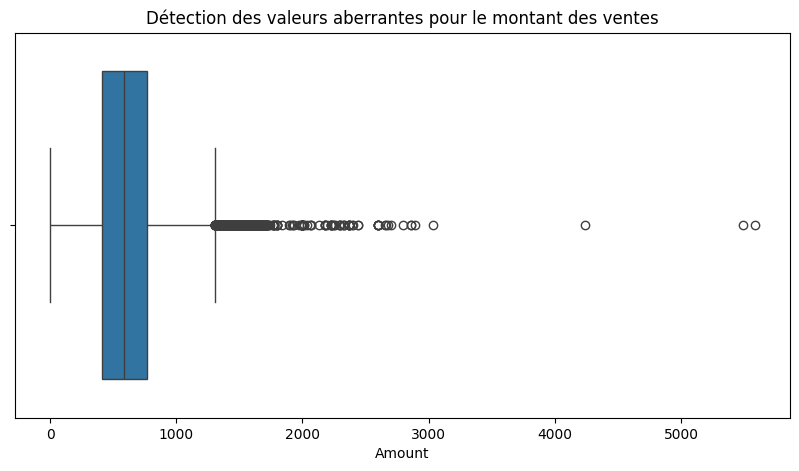

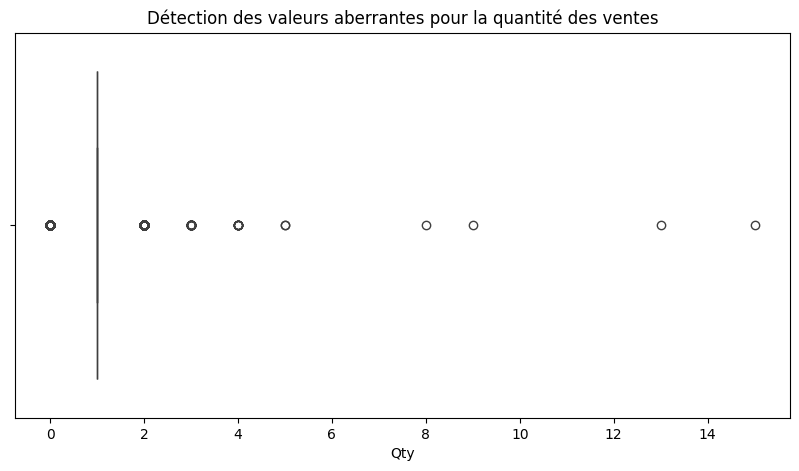

In [19]:
#detection des valeurs aberrantes

#cas amout
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_amazon['Amount'])
plt.title('Détection des valeurs aberrantes pour le montant des ventes')
plt.show()

#cas qty
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_amazon['Qty'])
plt.title('Détection des valeurs aberrantes pour la quantité des ventes')
plt.show()

# Analyse:

Le boxplot de l'**Amount** révèle de nombreuses valeurs aberrantes au-delà de la moustache supérieure. Ce ne sont pas forcément des erreurs, mais des commandes "premium" ou groupées qui impactent fortement le CA.

Pour la **Quantité,** les valeurs supérieures à 2 sont rares. Cela suggère un modèle de vente au détail (B2C) très marqué.

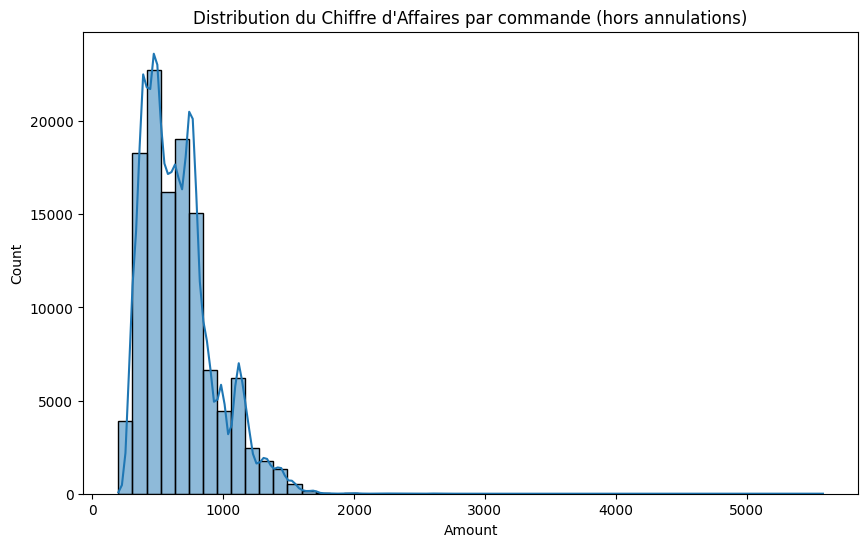

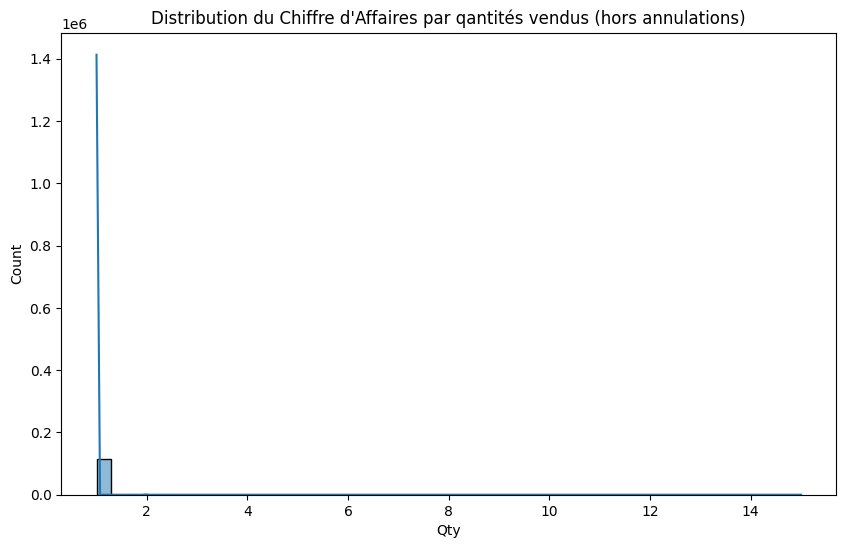

In [20]:
# Histogramme de la distribution des prix (Amount)
plt.figure(figsize=(10, 6))
sns.histplot(df_amazon[df_amazon['Amount'] > 0]['Amount'], bins=50, kde=True)
plt.title('Distribution du Chiffre d\'Affaires par commande (hors annulations)')
plt.show()

# Histogramme de la distribution des quantités de ventes  (QtY)
plt.figure(figsize=(10, 6))
sns.histplot(df_amazon[df_amazon['Qty'] > 0]['Qty'], bins=50, kde=True)
plt.title('Distribution du Chiffre d\'Affaires par qantités vendus (hors annulations)')
plt.show()

# **Analyse des performances**

Le Chiffre d'Affaires par Catégorie

/tmp/ipykernel_1251/2983029523.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ca_par_categorie.index, y=ca_par_categorie.values, palette='viridis')


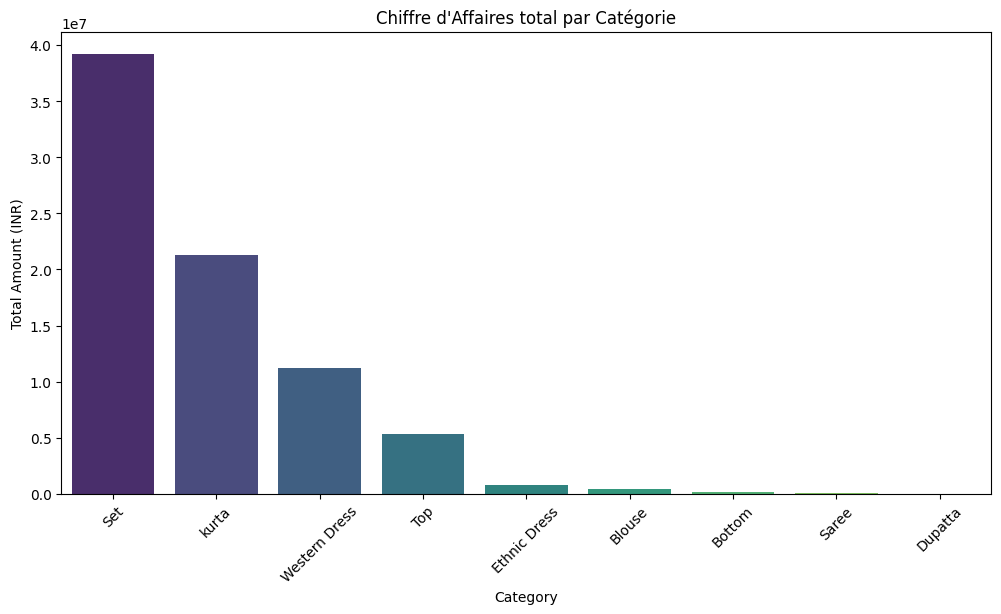

In [21]:
# Somme du CA par catégorie, triée par ordre décroissant
ca_par_categorie = df_amazon.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=ca_par_categorie.index, y=ca_par_categorie.values, palette='viridis')
plt.title('Chiffre d\'Affaires total par Catégorie')
plt.ylabel('Total Amount (INR)')
plt.xticks(rotation=45)
plt.show()

Le Chiffre d'Affaires par Type de Client

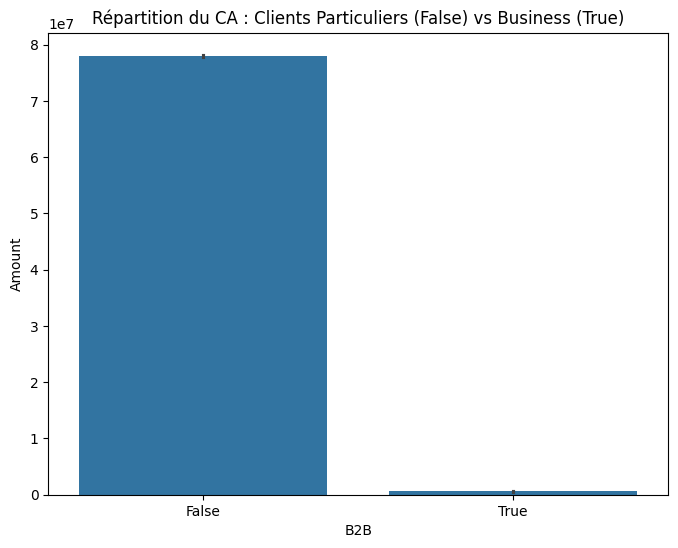

In [22]:
# Comparaison du panier moyen entre B2B et Particuliers
plt.figure(figsize=(8, 6))
sns.barplot(x='B2B', y='Amount', data=df_amazon, estimator=sum)
plt.title('Répartition du CA : Clients Particuliers (False) vs Business (True)')
plt.show()


Chiffre d'affaires par Statut de commande

/tmp/ipykernel_1251/2527430075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ca_statut.values, y=ca_statut.index, palette='magma')


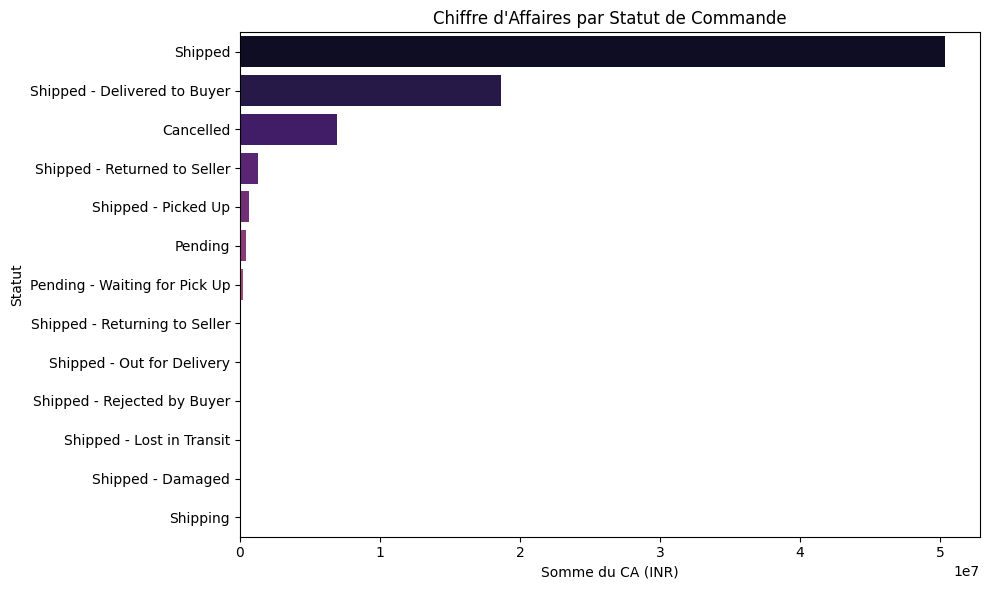

In [32]:
# CA par Statut de commande
ca_statut = df_amazon.groupby('Status')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=ca_statut.values, y=ca_statut.index, palette='magma')
plt.title('Chiffre d\'Affaires par Statut de Commande')
plt.xlabel('Somme du CA (INR)')
plt.ylabel('Statut')
plt.tight_layout()
plt.show()

Le CA par Taille

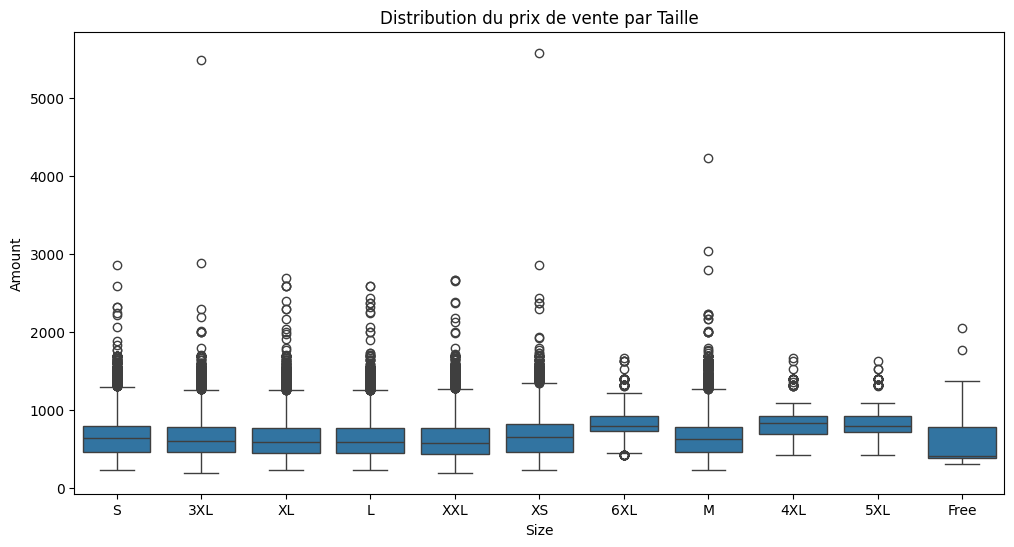

In [33]:
df_amazon['Size'].value_counts()
plt.figure(figsize=(12, 6))
sns.boxplot(x='Size', y='Amount', data=df_amazon[df_amazon['Amount'] > 0])
plt.title('Distribution du prix de vente par Taille')
plt.show()

Le CA par État

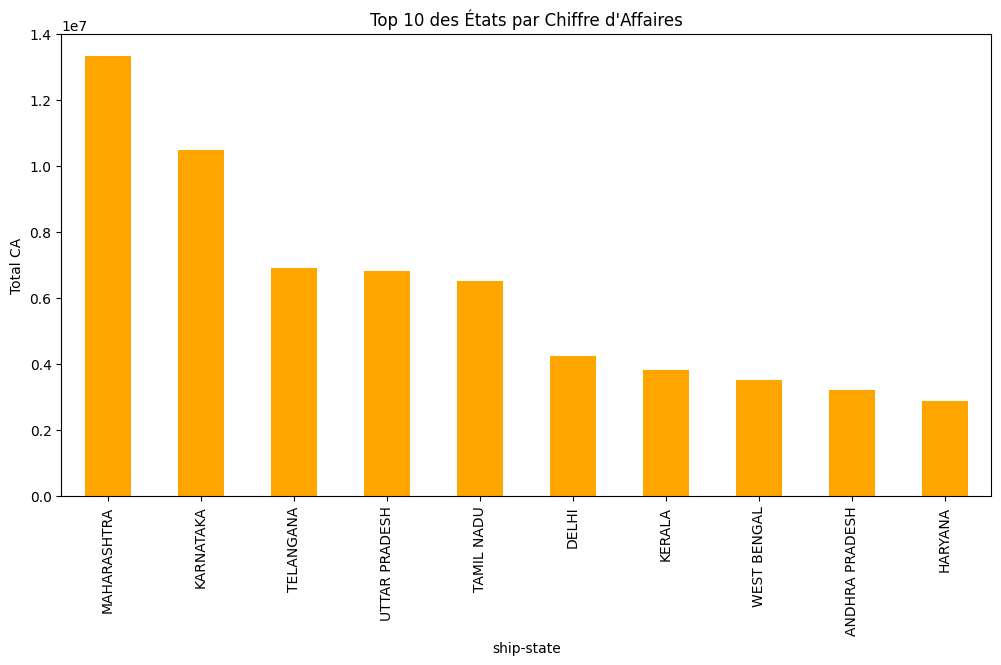

In [34]:
# Top 10 des états générant le plus de CA
top_states = df_amazon.groupby('ship-state')['Amount'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_states.plot(kind='bar', color='orange')
plt.title('Top 10 des États par Chiffre d\'Affaires')
plt.ylabel('Total CA')
plt.show()

CA par mois/saison

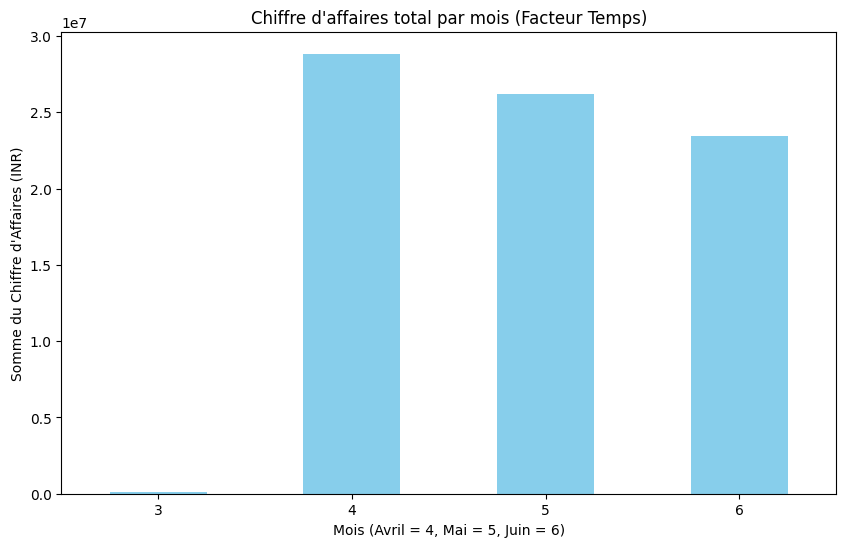

In [35]:
# 1. Création de la colonne Mois
df_amazon['Month'] = df_amazon['Date'].dt.month

# 2. Calcul et affichage du CA par mois
plt.figure(figsize=(10, 6))
df_amazon.groupby('Month')['Amount'].sum().plot(kind='bar', color='skyblue')

# 3. Ajout des détails pour le livrable
plt.title("Chiffre d'affaires total par mois (Facteur Temps)")
plt.xlabel("Mois (Avril = 4, Mai = 5, Juin = 6)")
plt.ylabel("Somme du Chiffre d'Affaires (INR)")
plt.xticks(rotation=0) # Pour que les numéros des mois soient droits
plt.show()

# Analyse des disctributions:

**Pour les Catégories :**

On voit tout de suite que ce sont les **Set** qui rapportent le plus d'argent. C'est le cœur du magasin. Si on devait faire de la pub, c'est sur ces produits qu'il faudrait miser.

**Pour les Statuts (Annulations) :**

Il y  a pas mal de commandes annulées. C'est de l'argent qu'on aurait pu gagner mais qui nous échappe. Il faudrait comprendre pourquoi les gens annulent autant.

**Pour le B2B :**

Les clients "Business" (entreprises) sont rares, mais quand ils achètent, ils prennent des plus gros montants. C'est un petit bonus pour le chiffre d'affaires.

**Pour le Facteur Temps (Le Mois):**

 On voit que le mois de **Avril** est celui qui a rapporté le plus d'argent. C'est un facteur super important : ça nous dit qu'à cette période, il se passe quelque chose (peut-être des fêtes ou des soldes) et qu'il faut être prêt à avoir du stock à ce moment-là.

**Pour la Taille (Size):**

D'après les boîtes à moustaches, la taille n'influence pas le prix (**la médiane est identique pour tous**).
Cependant, on voit beaucoup plus de points isolés (outliers) sur les tailles **M, L et XL**. Cela indique que ce sont les tailles les plus commandées (les plus populaires).

**Pour les États:**

 Le top 10 des États montre que **MAHARASTRA** est notre meilleur marché. C'est un facteur clé pour l'optimisation : on sait maintenant que c'est là-bas qu'on doit envoyer le plus de marchandises ou peut-être même y ouvrir un entrepôt pour livrer plus vite et gagner encore plus d'argent.

# **Skewness**

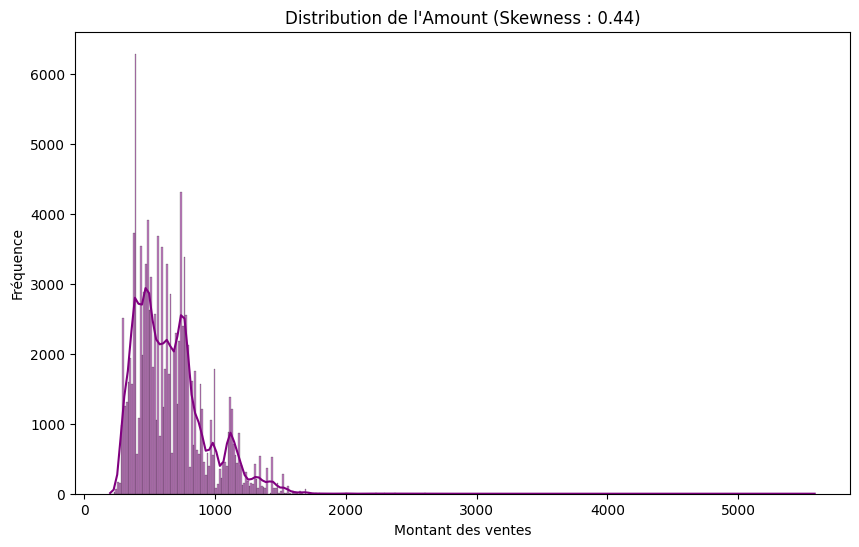

Le coefficient de skewness est de : 0.44


In [36]:
# 1. Calcul de la skewness
skew_amount = df_amazon['Amount'].skew()

# 2. Préparation du graphique
plt.figure(figsize=(10, 6))

# On filtre 'Amount > 0' pour mieux voir la forme (car les 0 écrasent le graphique)
sns.histplot(df_amazon[df_amazon['Amount'] > 0]['Amount'], kde=True, color='purple')

# 4. Habillage
plt.title(f"Distribution de l'Amount (Skewness : {skew_amount:.2f})")
plt.xlabel("Montant des ventes")
plt.ylabel("Fréquence")

# 5. Affichage
plt.show()

print(f"Le coefficient de skewness est de : {skew_amount:.2f}")


# Analyse:
Le coefficient de Skewness est de **0,44**. Étant **positif et supérieur à 1**, il confirme une **asymétrie positive forte**.

Le graphique penche énormément vers la gauche. Ça veut dire que notre business tourne grâce à beaucoup de petites ventes pas chères.

On ne vend pas beaucoup de produits "luxe", on est plutôt sur une boutique de gros volume avec des prix accessibles.

## Conclusion : Facteurs clés et Optimisation
Suite à cette analyse, nous identifions trois facteurs majeurs influençant le chiffre d'affaires :
1. **Le Type de Produit** : Les Set sont les moteurs de vente.
2. **La Saisonnalité** : Le mois de Avril est le plus performant.
3. **Le Statut de Livraison** : Le volume d'annulations impacte significativement le résultat net.

**Recommandations pour optimiser la performance :**
* Prioriser le réapprovisionnement des tailles M,L et XL dans la catégorie Set.
* Lancer des promotions ciblées durant les mois creux pour lisser le CA annuel.
* Analyser les causes de retours/annulations dans l'état de  MAHARASTRA pour sécuriser le CA.